# Nanoplasma reduced-H5 plotting notebook (no openPMD)

This notebook reproduces the main paper-style plots **directly from the reduced HDF5 files**.

Expected top-level H5 groups:
`axes`, `timeseries`, `spectra`, `radial`, `slices`, (optional) `macrocell3d`, (optional) `meta`

---

## What is possible from your current reduced H5?

Given your inventory:

- **Figure 1 storyboard (maps)** ✅ from `/slices`
- **Ne(t), dNe/dt** ✅ from `/timeseries/He_e_N_real` (or `N_macro`)
- **Mean energies / temperatures** ✅ from `/timeseries/*Ekin*`, `*T_mean_eV`, `*T_tail_eV`
- **Charge-state evolution** ✅ from `/timeseries/He_i_charge_frac`, `/timeseries/He_i_Z_mean`, and `/radial/He_i_charge_rZ_counts`
- **Radial expansion (R(t), mean radius, rms)** ✅ from `/radial/He_i_n_r` and `axes/r_mid_m`
- **Net charge vs radius/time** ✅ from `/radial/rho_net_shell_C` + `shell_volume_m3` (see notes in code)
- **Electron & ion spectra heatmaps** ✅ from `/spectra/*_dNdE` and `axes/E_mid_eV`
- **Angular (mu) heatmap + asymmetry** ✅ from `/spectra/He_e_dNdmu` and `axes/mu_mid`
- **Phase shift of plasma dipole vs laser field** ❌ not possible unless you also store a time-resolved dipole moment `d(t)` and laser field `E(t)` (or a proxy at the droplet center). You can add those to the exporter later.

If you later add `spectra/*_H_pxy` (2D momentum histogram), this notebook includes an optional VMI panel.


In [37]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ---------- USER INPUT ----------
H5_IONIZED = r"/p/scratch/jureap18/medina2/2026_nanoplasma/Run001_reduced.h5"
H5_NEUTRAL = r"/p/scratch/jureap18/medina2/2026_nanoplasma/Run002_reduced.h5"   # neutral-start
# --------------------------------

def h5_inventory(path):
    with h5py.File(path, "r") as f:
        inv = {}
        for k in f.keys():
            inv[k] = list(f[k].keys()) if isinstance(f[k], h5py.Group) else []
        return inv

def h5_read(path, dset):
    with h5py.File(path, "r") as f:
        return np.array(f[dset])

def h5_has(path, dset):
    with h5py.File(path, "r") as f:
        return dset in f

def load_axes(path):
    axes = {}
    with h5py.File(path, "r") as f:
        for k in f["axes"].keys():
            axes[k] = np.array(f["axes"][k])
    return axes

def load_timeseries(path):
    ts = {}
    with h5py.File(path, "r") as f:
        for k in f["timeseries"].keys():
            ts[k] = np.array(f["timeseries"][k])
    return ts

def load_spectra(path):
    sp = {}
    with h5py.File(path, "r") as f:
        for k in f["spectra"].keys():
            sp[k] = np.array(f["spectra"][k])
    return sp

def load_radial(path):
    rd = {}
    with h5py.File(path, "r") as f:
        for k in f["radial"].keys():
            rd[k] = np.array(f["radial"][k])
    return rd

def list_slice_steps(path):
    with h5py.File(path, "r") as f:
        if "slices" not in f:
            return []
        return sorted(list(f["slices"].keys()))

def read_slice(path, step_key, name):
    dset = f"slices/{step_key}/{name}"
    return h5_read(path, dset)

def parse_step(step_key):
    # "step_00190000" -> 190000
    return int(step_key.split("_",1)[1])

def available_slice_fields(path, step_key):
    with h5py.File(path, "r") as f:
        return list(f["slices"][step_key].keys())

## 0) Sanity check: what’s in the files

In [38]:
for label, p in [("IONIZED", r"/p/scratch/jureap18/medina2/2026_nanoplasma/Run002_reduced.h5" ), ("NEUTRAL", H5_NEUTRAL)]:
    print("\n===", label, "===")
    inv = h5_inventory(p)
    for k in inv:
        print(f"{k:12s} -> {inv[k][:12]}{' ...' if len(inv[k])>12 else ''}")



=== IONIZED ===
axes         -> ['E_edges_eV', 'E_mid_eV', 'He_e_p_edges_SI', 'He_e_p_mid_SI', 'He_i_p_edges_SI', 'He_i_p_mid_SI', 'mu_edges', 'mu_mid', 'r_edges_m', 'r_mid_m', 'time_fs']
macrocell3d  -> ['step_00000000', 'step_00010000', 'step_00020000', 'step_00030000', 'step_00040000', 'step_00050000', 'step_00060000', 'step_00070000', 'step_00080000', 'step_00090000', 'step_00100000', 'step_00110000'] ...
meta         -> []
radial       -> ['He_e_n_r', 'He_i_charge_rZ_counts', 'He_i_n_r', 'Z_values', 'rho_net_shell_C', 'shell_volume_m3']
slices       -> ['step_00000000', 'step_00010000', 'step_00020000', 'step_00030000', 'step_00040000', 'step_00050000', 'step_00060000', 'step_00070000', 'step_00080000', 'step_00090000', 'step_00100000', 'step_00110000'] ...
spectra      -> ['He_e_H_pxy', 'He_e_dEdmu', 'He_e_dNdE', 'He_e_dNdmu', 'He_i_H_pxy', 'He_i_dNdE']
timeseries   -> ['He_e_Ekin_mean_eV', 'He_e_Ekin_total_eV', 'He_e_N_macro', 'He_e_N_real', 'He_e_P_total_SI', 'He_e_T_mean_eV',

# Figure 1 — Storyboard maps from `/slices`

This reproduces your “movie condensed” panel.  
It uses whatever slice datasets are available per step. Because exporter conventions can differ, this cell tries common names and prints what it finds.

**Tip:** Use exactly the same selected steps for both runs for clean side-by-side figures.


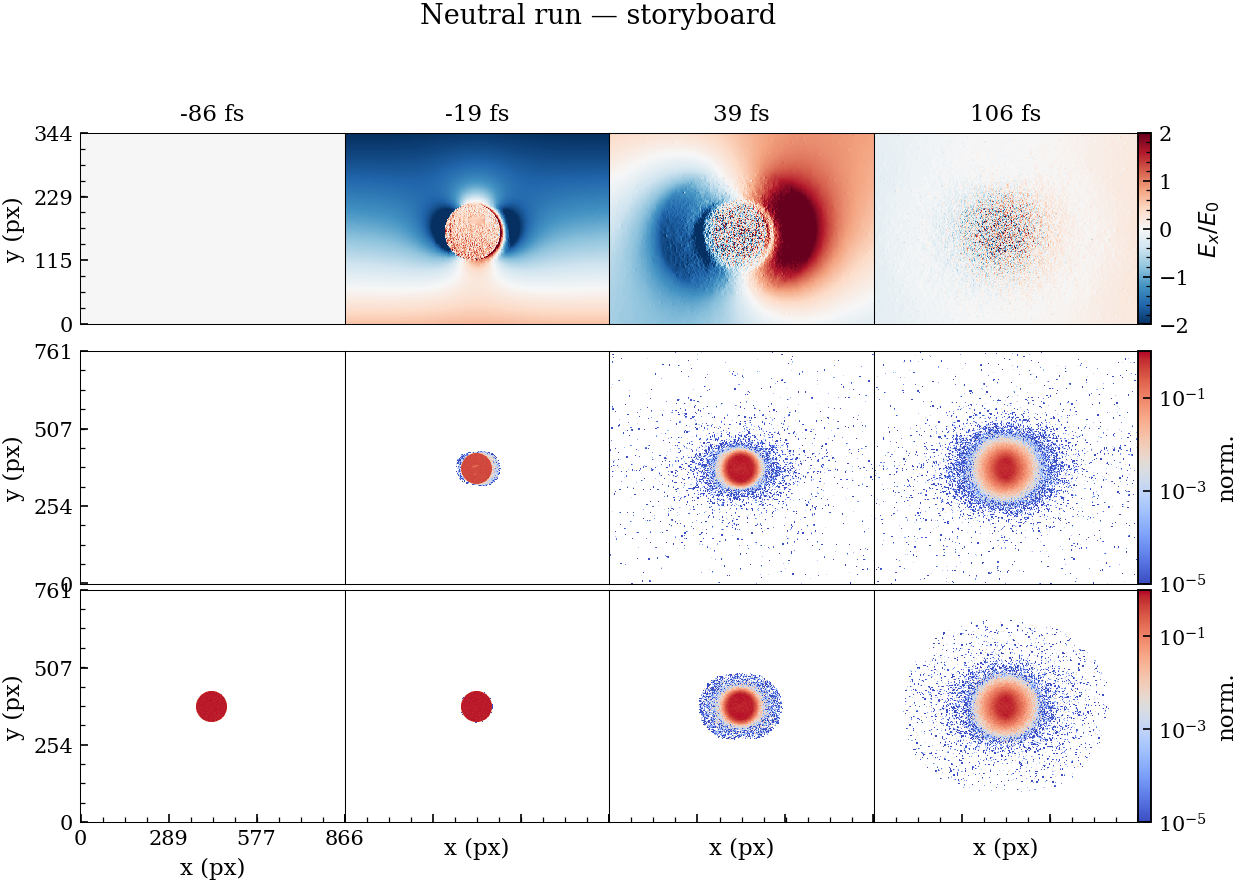

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import scipy.constants as sc

# -------- knobs --------
n_frames = 4
I0_Wcm2 = 1e14
field_vlim = 2.0
lognorm_vmin = 1e-5

pad_px_field = 100      # crop padding for field (XY)
pad_px_xz = 100         # crop padding for densities (XZ)

crop_thr_field = 0.5  # threshold on |Ex/E0| for crop (relative to max)
crop_thr_ions  = 1e-3  # threshold on normalized ion density for crop
# ----------------------
def get_pixel_size_nm_from_meta(path):
    """Return (dx_nm, dy_nm, dz_nm) if stored, else None."""
    import h5py
    with h5py.File(path, "r") as f:
        if "meta" not in f:
            return None
        m = f["meta"]
        # flexible names if you add them later
        keys = list(m.keys())
        def read_any(cands):
            for c in cands:
                if c in m:
                    return float(np.array(m[c]))
            return None
        Dx = read_any(["Dx_SI", "cell_width_SI", "dx_SI"])
        Dy = read_any(["Dy_SI", "cell_height_SI", "dy_SI"])
        Dz = read_any(["Dz_SI", "cell_depth_SI", "dz_SI"])
    if Dx is None or Dy is None or Dz is None:
        return None
    return Dx*1e9, Dy*1e9, Dz*1e9  # nm

def set_ticks(ax, shape, dx_nm=None, dy_nm=None, nticks=4, which="x"):
    """Set nice ticks in nm if dx_nm/dy_nm provided, else pixel indices."""
    ny, nx = shape
    if which in ("x", "both"):
        xs = np.linspace(0, nx-1, nticks).round().astype(int)
        ax.set_xticks(xs)
        if dx_nm is not None:
            ax.set_xticklabels([f"{x*dx_nm:.0f}" for x in xs])
            ax.set_xlabel("x (nm)")
        else:
            ax.set_xticklabels([str(x) for x in xs])
            ax.set_xlabel("x (px)")
    if which in ("y", "both"):
        ys = np.linspace(0, ny-1, nticks).round().astype(int)
        ax.set_yticks(ys)
        if dy_nm is not None:
            ax.set_yticklabels([f"{y*dy_nm:.0f}" for y in ys])
            ax.set_ylabel("y (nm)")
        else:
            ax.set_yticklabels([str(y) for y in ys])
            ax.set_ylabel("y (px)")
            
def pick_even(step_keys, n_frames=6):
    step_keys = list(step_keys)
    if len(step_keys) <= n_frames:
        return step_keys
    idx = np.linspace(0, len(step_keys)-1, n_frames).round().astype(int)
    idx = np.unique(idx)
    while len(idx) < n_frames:
        missing = [i for i in range(len(step_keys)) if i not in idx]
        if not missing: break
        idx = np.sort(np.concatenate([idx, [missing[len(missing)//2]]]))
    return [step_keys[i] for i in idx[:n_frames]]

def union_bbox_from_threshold(A_list, thr_rel=1e-3, use_abs=True):
    """
    Build a union bbox over frames where (A / max(A)) > thr_rel.
    Returns (x0,x1,y0,y1) in pixel indices for arrays shaped (Y,X).
    """
    boxes = []
    for A in A_list:
        B = np.abs(A) if use_abs else A
        m = np.nanmax(B) + 1e-300
        Bn = B / m
        idx = np.argwhere(Bn > thr_rel)
        if idx.size == 0:
            continue
        y0, x0 = idx.min(axis=0)
        y1, x1 = idx.max(axis=0)
        boxes.append((x0,x1,y0,y1))
    if not boxes:
        return None
    x0 = min(b[0] for b in boxes)
    x1 = max(b[1] for b in boxes)
    y0 = min(b[2] for b in boxes)
    y1 = max(b[3] for b in boxes)
    return x0,x1,y0,y1

def crop2(A, bbox, pad=20):
    if bbox is None:
        return A
    x0,x1,y0,y1 = bbox
    x0 = max(0, x0-pad); y0 = max(0, y0-pad)
    x1 = min(A.shape[1]-1, x1+pad)
    y1 = min(A.shape[0]-1, y1+pad)
    return A[y0:y1+1, x0:x1+1]

def get_times_for_slices(path, sel_steps):
    all_steps = list_slice_steps(path)
    t = None
    try:
        axes = load_axes(path)
        t = axes.get("time_fs", None)
    except Exception:
        t = None
    if t is not None and len(t) == len(all_steps):
        m = {sk: float(t[i]) for i, sk in enumerate(all_steps)}
        return [m.get(sk, np.nan) for sk in sel_steps]
    return [np.nan]*len(sel_steps)

def plot_storyboard_horizontal_paper(path, title, n_frames=6):
    all_steps = list_slice_steps(path)
    sel_steps = pick_even(all_steps, n_frames=n_frames)
    t_list = get_times_for_slices(path, sel_steps)

    # required datasets
    f0 = available_slice_fields(path, sel_steps[0])
    for need in ("Ex_xy_SI", "rho_e_xz_SI", "rho_i_xz_SI"):
        if need not in f0:
            raise RuntimeError(f"Missing {need} in slices/{sel_steps[0]}: {f0}")

    # load frames
    Ex_list, rhoe_list, rhoi_list = [], [], []
    for sk in sel_steps:
        Ex_list.append(np.squeeze(read_slice(path, sk, "Ex_xy_SI")))      # XY
        rhoe_list.append(np.squeeze(read_slice(path, sk, "rho_e_xz_SI"))) # XZ
        rhoi_list.append(np.squeeze(read_slice(path, sk, "rho_i_xz_SI"))) # XZ

    # normalize E like ana_final: Ex/E0
    E0 = np.sqrt(2.0 * I0_Wcm2 * 1e4 / (sc.c * sc.epsilon_0))
    Exn_list = [A/(E0+1e-300) for A in Ex_list]

    # normalize densities to global max across frames + lognorm
    max_rhoe = np.nanmax([np.nanmax(np.abs(A)) for A in rhoe_list]) + 1e-300
    max_rhoi = np.nanmax([np.nanmax(np.abs(A)) for A in rhoi_list]) + 1e-300
    rhoeN = []
    rhoiN = []
    
    for A in rhoe_list:
        B = np.abs(A) / (max_rhoe + 1e-300)
        B[B <= 0] = np.nan     # mask zeros
        rhoeN.append(B)
    
    for A in rhoi_list:
        B = np.abs(A) / (max_rhoi + 1e-300)
        B[B <= 0] = np.nan     # mask zeros
        rhoiN.append(B)
    
    rho_norm = LogNorm(vmin=lognorm_vmin, vmax=1.0)

    # --------- NEW: separate crop boxes ----------
    # Crop XZ based on ions (good for droplet region)
    bbox_xz = union_bbox_from_threshold(rhoi_list, thr_rel=crop_thr_ions, use_abs=True)

    # Crop XY based on field (where |Ex/E0| is significant)
    bbox_xy = union_bbox_from_threshold(Exn_list, thr_rel=crop_thr_field, use_abs=True)

    # apply crops
    Exn_list = [crop2(A, bbox_xy, pad_px_field) for A in Exn_list]
    rhoeN    = [crop2(A, bbox_xz, pad_px_xz)    for A in rhoeN]
    rhoiN    = [crop2(A, bbox_xz, pad_px_xz)    for A in rhoiN]
    # -------------------------------------------

    # ---- paper-like rcParams ----
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 11,
        "axes.labelsize": 11,
    })

    # layout: 3 rows + skinny colorbar column
    ncols = len(sel_steps)
    fig = plt.figure(figsize=(2.0*ncols +1.21 , 6.2))
    gs = fig.add_gridspec(
        nrows=3, ncols=ncols+1,
        width_ratios=[1]*ncols + [0.05],
        wspace=0.0, hspace=0.00
    )

    ims_E = []
    ims_e = []
    ims_i = []
    pix = get_pixel_size_nm_from_meta(H5_IONIZED)  # None if not stored
    # For Ex_xy: axes are (y,x) so use dy,dx
    # For rho_xz: axes are (z,x) so use dz,dx
    dx_nm = pix[0] if pix else None
    dy_nm = pix[1] if pix else None
    dz_nm = pix[2] if pix else None

    for j in range(ncols):
        ttl = f"{t_list[j]:.0f} fs" if np.isfinite(t_list[j]) else f"{parse_step(sel_steps[j])}"

        axE  = fig.add_subplot(gs[0, j])
        axNe = fig.add_subplot(gs[1, j])
        axNi = fig.add_subplot(gs[2, j])

        imE = axE.imshow(Exn_list[j], cmap="RdBu_r", origin="lower",
                         interpolation="nearest", vmin=-field_vlim, vmax=field_vlim,
                         aspect="equal")
        imNe = axNe.imshow(rhoeN[j], cmap="coolwarm", origin="lower",
                           interpolation="nearest", norm=rho_norm, aspect="equal")
        imNi = axNi.imshow(rhoiN[j], cmap="coolwarm", origin="lower",
                           interpolation="nearest", norm=rho_norm, aspect="equal")

        ims_E.append(imE); ims_e.append(imNe); ims_i.append(imNi)
  
        for ax in (axE, axNe, axNi):
            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values():
                sp.set_visible(True)
                sp.set_linewidth(0.5)
                sp.set_color("black")

        axE.set_title(ttl)

        if j == 0:
            axE.set_ylabel(r"$E_x/E_0$")
            axNe.set_ylabel(r"$|\rho_e|$")
            axNi.set_ylabel(r"$|\rho_i|$")
        # inside: for j in range(ncols):
        
        # show y ticks only on first column
        if j == 0:
            set_ticks(axE,  Exn_list[j].shape, dx_nm=dx_nm, dy_nm=dy_nm, which="y")
            set_ticks(axNe, rhoeN[j].shape,    dx_nm=dx_nm, dy_nm=dz_nm, which="y")  # z-axis
            set_ticks(axNi, rhoiN[j].shape,    dx_nm=dx_nm, dy_nm=dz_nm, which="y")  # z-axis
        # bottom-row x tick labels: only keep on first column (j==0)
        if j != 0:
            axNi.tick_params(labelbottom=False)   # hides the numbers, keeps tick marks
        # show x ticks only on bottom row — do it for ALL columns (or just leftmost if you prefer)
        set_ticks(axNi, rhoiN[j].shape, dx_nm=dx_nm, dy_nm=dz_nm, which="x")

    # shared colorbars (one per row) in last column
    caxE  = fig.add_subplot(gs[0, -1])
    caxe  = fig.add_subplot(gs[1, -1])
    caxi  = fig.add_subplot(gs[2, -1])

    cbE = fig.colorbar(ims_E[-1], cax=caxE)
    cbe = fig.colorbar(ims_e[-1], cax=caxe)
    cbi = fig.colorbar(ims_i[-1], cax=caxi)
    cbE = fig.colorbar(ims_E[-1], cax=caxE)
    cbe = fig.colorbar(ims_e[-1], cax=caxe)
    cbi = fig.colorbar(ims_i[-1], cax=caxi)
    # --- match colorbar height to the corresponding row axes height ---
    # pick any axis from that row (I use last column axis from each row)
    bboxE  = axE.get_position()   # last created axE in the loop is last column
    bboxNe = axNe.get_position()
    bboxNi = axNi.get_position()
    
    for cax, bbox in [(caxE, bboxE), (caxe, bboxNe), (caxi, bboxNi)]:
        p = cax.get_position()
        cax.set_position([p.x0, bbox.y0, p.width, bbox.height])
        
    cbE.set_label(r"$E_x/E_0$")
    cbe.set_label("norm.")
    cbi.set_label("norm.")

    fig.suptitle(title, y=0.995, fontsize=13)
  
    plt.show()
# Run
#plot_storyboard_horizontal_paper(H5_IONIZED, "Pre-ionized run — storyboard", n_frames=n_frames)
plot_storyboard_horizontal_paper(H5_NEUTRAL, "Neutral run — storyboard", n_frames=n_frames)

# Figure 2 — Ignition + collective dynamics (timeseries + radial)

Panels you can do from reduced H5:

- $N_e(t)$ and $dN_e/dt$ (electron yield / avalanche signature)
- Ion charge state: $\langle Z \rangle(t)$ and charge fractions
- Expansion: $\langle r \rangle(t)$ and/or $R_{99}(t)$ from ion radial distribution
- Net charge inside droplet vs time (approximate, see notes)



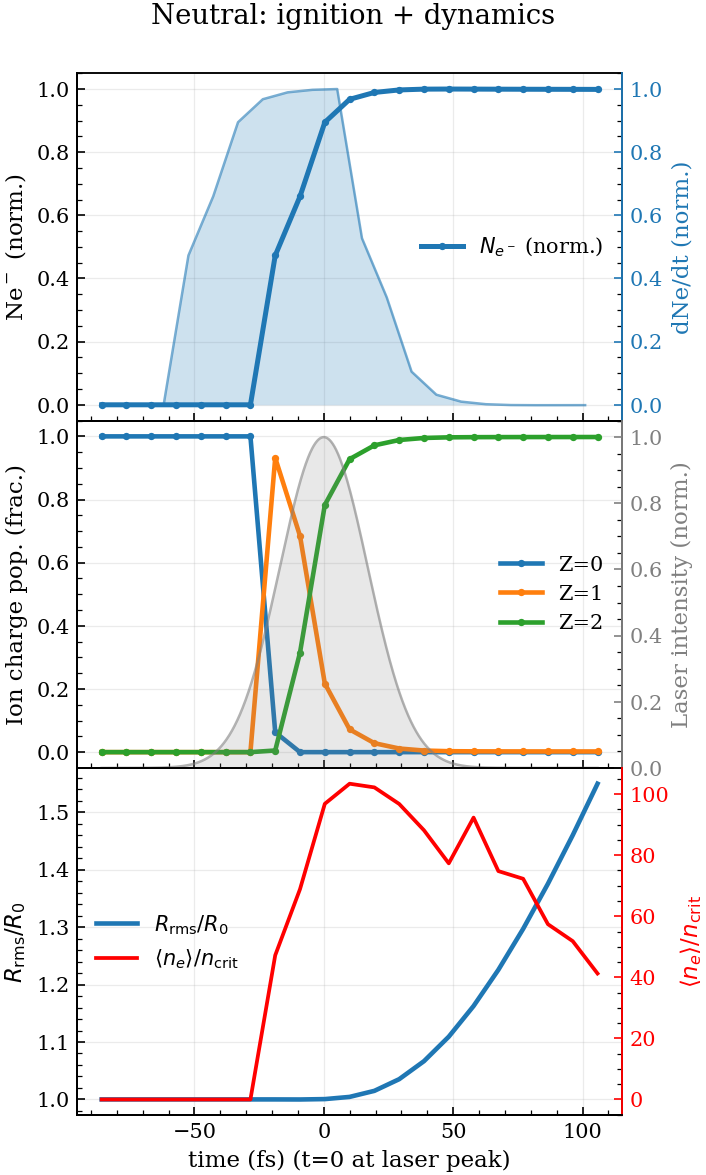

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- user knobs ----------
TAU_FWHM_FS = 40.0          # laser intensity FWHM (fs)
NORM_RATE_SMOOTH = 7        # odd integer window for simple moving-average smoothing of dNe/dt
SHOW_Z = (0, 1, 2)          # Z lines to show in middle panel
# -------------------------------

def movavg(y, w):
    w = int(w)
    if w < 3 or w % 2 == 0:
        return y
    k = w // 2
    ypad = np.pad(y, (k, k), mode="edge")
    return np.convolve(ypad, np.ones(w)/w, mode="valid")

def gaussian_envelope(t_fs, fwhm_fs):
    # normalized intensity envelope, peak at t=0
    return np.exp(-4*np.log(2) * (t_fs / fwhm_fs)**2)

def ddt_midpoints(t_fs, y):
    t = np.asarray(t_fs)
    y = np.asarray(y)
    dt = np.diff(t)
    dy = np.diff(y)
    tmid = 0.5*(t[1:] + t[:-1])
    return tmid, dy/(dt + 1e-300)

def plot_figure2_ignition(path, title):
    axes = load_axes(path)
    ts = load_timeseries(path)
    rd = load_radial(path)

    t = axes["time_fs"]

    # ---------- TOP: electron population (normalized) + creation rate (background) ----------
    if "He_e_N_real" in ts:
        Ne = ts["He_e_N_real"].astype(float)
    else:
        Ne = ts["He_e_N_macro"].astype(float)

    Ne_norm = Ne / (np.nanmax(Ne) + 1e-300)
    tmid, dNe_dt = ddt_midpoints(t, Ne_norm)
    dNe_dt = movavg(dNe_dt, NORM_RATE_SMOOTH)
    # normalize rate for a nice filled background
    dNe_dt_norm = dNe_dt / (np.nanmax(np.abs(dNe_dt)) + 1e-300)

    # ---------- MIDDLE: ion charge populations Z=0,1,2 (normalized) + laser envelope background ----------
    if "He_i_charge_frac" not in ts:
        raise RuntimeError("Missing timeseries/He_i_charge_frac in reduced H5. "
                           "You need this for Z=0/1/2 ionization evolution.")
    fracZ = ts["He_i_charge_frac"]  # expected shape (Nt, Zmax+1)
    if fracZ.ndim != 2:
        raise RuntimeError(f"Unexpected He_i_charge_frac shape: {fracZ.shape}")

    # ensure rows correspond to time
    if fracZ.shape[0] != len(t) and fracZ.shape[1] == len(t):
        fracZ = fracZ.T

    # ---------- BOTTOM: ion expansion R99/R0 ----------
    r_mid = axes["r_mid_m"]
    n_r = rd["He_i_n_r"]
    # orient (Nt, Nr)
    if n_r.shape[0] == len(t) and n_r.shape[1] == len(r_mid):
        n_t_r = n_r
    elif n_r.shape[1] == len(t) and n_r.shape[0] == len(r_mid):
        n_t_r = n_r.T
    else:
        raise RuntimeError(f"He_i_n_r shape {n_r.shape} does not match (Nt,Nr)=({len(t)},{len(r_mid)})")

    n_t_r = np.maximum(n_t_r, 0.0)
    cdf = np.cumsum(n_t_r, axis=1)
    tot = cdf[:, -1] + 1e-300
    frac = cdf / tot[:, None]
    R99 = np.array([r_mid[min(np.searchsorted(frac[i], 0.99), len(r_mid)-1)] for i in range(len(t))])
    R0 = R99[0] if R99[0] > 0 else (np.nanmax(R99) + 1e-300)
    R99_over_R0 = R99 / (R0 + 1e-300)

    # ---------- figure styling ----------
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
    })

    fig, ax = plt.subplots(3, 1, figsize=(5,8), sharex=True,
                           gridspec_kw={"hspace": 0.0})

    # ---- TOP panel ----
     # Electron population (left axis)
    Ne_line = ax[0].plot(t, Ne_norm, ".-",lw=2.4, label=r"$N_{e^-}$ (norm.)")
    color_Ne = Ne_line[0].get_color()

    ax[0].set_ylabel(f"Ne$^-$ (norm.)")
    ax[0].set_ylim(-0.05, 1.05)
    ax[0].grid(True, alpha=0.25)

    # Electron creation rate (right axis)
    ax_rate = ax[0].twinx()
    # normalize rate independently for visual clarity
    dNe_dt_norm2 = dNe_dt / (np.nanmax(np.abs(dNe_dt)) + 1e-300)
    ax_rate.fill_between(tmid,dNe_dt_norm2,0,color=color_Ne,alpha=0.22,lw=0,label="dNe/dt (norm.)"    )
    ax_rate.plot(tmid,dNe_dt_norm2,color=color_Ne,alpha=0.6,lw=1.2)
    ax_rate.set_ylabel("dNe/dt (norm.)", color=color_Ne)
    ax_rate.tick_params(axis="y", colors=color_Ne)
    ax_rate.spines["right"].set_color(color_Ne)
    ax_rate.set_ylim(-0.05, 1.05)
    # cleaner look
    ax_rate.spines["top"].set_visible(False)
    ax[0].legend(loc="center right",frameon=False)   
    
    # ---- MIDDLE panel ----
    # Ion charge populations on left axis
    for Z in SHOW_Z:
        if Z < fracZ.shape[1]:
            ax[1].plot(t, fracZ[:, Z], ".-", lw=2.2, label=f"Z={Z}")

    ax[1].set_ylabel("Ion charge pop. (frac.)")
    ax[1].set_ylim(-0.05, 1.05)
    ax[1].grid(True, alpha=0.25)

    # Laser envelope on right axis
    ax_laser = ax[1].twinx()
    laser_color="gray"
    
        # Laser envelope on a dense time grid (smooth)
    t_dense = np.linspace(np.nanmin(t), np.nanmax(t), 1500)
    Ienv_dense = gaussian_envelope(t_dense, TAU_FWHM_FS)
    Ienv_dense /= (np.max(Ienv_dense) + 1e-300)
    
    ax_laser.fill_between(t_dense, Ienv_dense, 0, color="gray", alpha=0.18, lw=0, label="Laser envelope")
    ax_laser.plot(t_dense, Ienv_dense, color="gray", alpha=0.6, lw=1.2)
    ax_laser.set_ylim(0, 1.05)
    ax_laser.set_ylabel("Laser intensity (norm.)",color=laser_color)
    # color right axis ticks + spine
    ax_laser.tick_params(axis="y", colors=laser_color)
    ax_laser.spines["right"].set_color(laser_color)
    # cleaner look
    ax_laser.spines["top"].set_visible(False)
    ax[1].legend(loc="center right", frameon=False)
    
    # ---- BOTTOM panel: R_rms/R0 (ions) + <n_e>/ncrit (inside R_rms) ----
    LAMBDA_NM = 800.0  # set to your laser wavelength
    
    def orient_to_t_r(A, Nt, Nr):
        A = np.asarray(A)
        if A.shape == (Nt, Nr):
            return A
        if A.shape == (Nr, Nt):
            return A.T
        raise RuntimeError(f"Expected (Nt,Nr)=({Nt},{Nr}) or (Nr,Nt), got {A.shape}")
    
    Nr = len(r_mid)
    Nt = len(t)
    
    n_i_t_r = orient_to_t_r(rd["He_i_n_r"], Nt, Nr)
    n_e_t_r = orient_to_t_r(rd["He_e_n_r"], Nt, Nr)
    
    n_i_t_r = np.maximum(n_i_t_r, 0.0)
    n_e_t_r = np.maximum(n_e_t_r, 0.0)
    
    # --- Ion rms radius ---
    Ni = np.sum(n_i_t_r, axis=1) + 1e-300
    r2_mean = np.sum(n_i_t_r * (r_mid[None, :]**2), axis=1) / Ni
    Rrms = np.sqrt(np.maximum(r2_mean, 0.0))
    
    R0 = Rrms[0] if Rrms[0] > 0 else (np.nanmax(Rrms) + 1e-300)
    Rrms_over_R0 = Rrms / (R0 + 1e-300)
    
    # --- Electron mean density inside Rrms ---
    # electrons inside Rrms: sum shells with r_mid <= Rrms(t)
    Ne_in = np.zeros(Nt)
    for i in range(Nt):
        mask = r_mid <= Rrms[i]
        Ne_in[i] = np.sum(n_e_t_r[i, mask])
    
    V_sphere = (4.0/3.0) * np.pi * (Rrms**3 + 1e-300)
    ne_mean = Ne_in / V_sphere  # 1/m^3
    
    # --- Critical density ---
    lam_m = LAMBDA_NM * 1e-9
    omega = 2.0*np.pi*sc.c/lam_m
    ncrit = sc.epsilon_0 * sc.m_e * omega**2 / sc.e**2  # 1/m^3
    
    ne_over_ncrit = ne_mean / (ncrit + 1e-300)
    
    # Plot left axis: radius
    ax[2].plot(t, Rrms_over_R0, lw=2.2, label=r"$R_{\rm rms}/R_0$")
    ax[2].set_ylabel(r"$R_{\rm rms}/R_0$")
    ax[2].grid(True, alpha=0.25)
    
    # Plot right axis: density in units of ncrit
    ax_den = ax[2].twinx()
    den_color = "red"
    ax_den.plot(t, ne_over_ncrit, lw=1.8, color=den_color, label=r"$\langle n_e\rangle/n_{\rm crit}$")
    #ax_den.set_yscale("log")
    ax_den.set_ylabel(r"$\langle n_e\rangle/n_{\rm crit}$", color=den_color)
    ax_den.tick_params(axis="y", colors=den_color)
    ax_den.spines["right"].set_color(den_color)
    ax_den.spines["top"].set_visible(False)
    ax[2].set_xlabel("time (fs) (t=0 at laser peak)")
    
    # Combined legend (bottom)
    ax[2].legend(
        [ax[2].lines[-1], ax_den.lines[-1]],
        [r"$R_{\rm rms}/R_0$", r"$\langle n_e\rangle/n_{\rm crit}$"],
        loc="center left",
        frameon=False
    )
    fig.suptitle(title, y=0.995)
    plt.tight_layout()
    plt.show()

# Run both cases
#plot_figure2_ignition(H5_IONIZED, "Pre-ionized: ignition + dynamics")
plot_figure2_ignition(H5_NEUTRAL, "Neutral: ignition + dynamics")

In [11]:
plot_ignition_dynamics

<function __main__.plot_ignition_dynamics(path, label)>

# Figure 3 — Angular anisotropy / asymmetry vs time (from dN/dμ)

From your reduced H5 you can compute a clean **forward-backward asymmetry** along the chosen axis from the stored `He_e_dNdmu(t,μ)`.

Define:
- forward = μ>0
- backward = μ<0
- $A(t) = (N_+ - N_-)/(N_+ + N_-)$

This is a strong “collective” diagnostic without needing raw momenta.

**Note:** the *phase-shift* analysis (dipole vs laser E) is not possible unless you export a dipole moment time series.


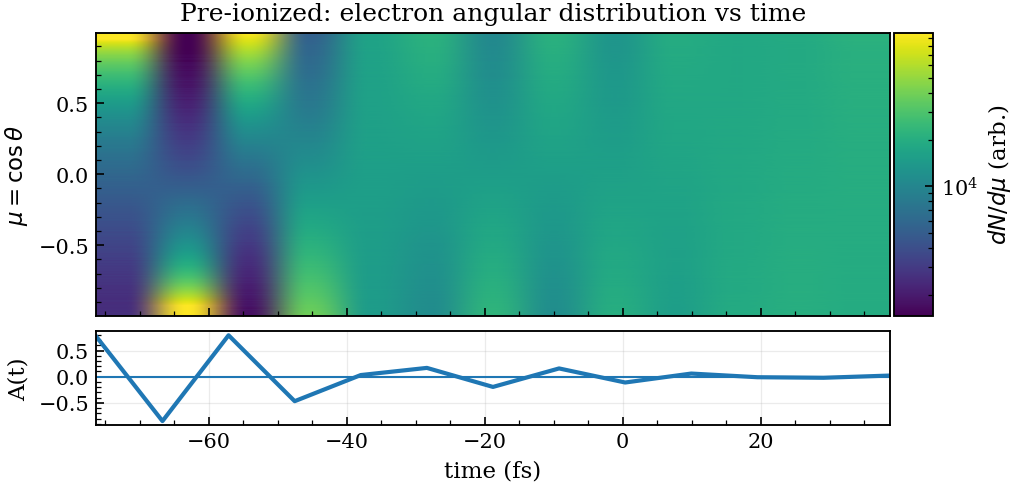

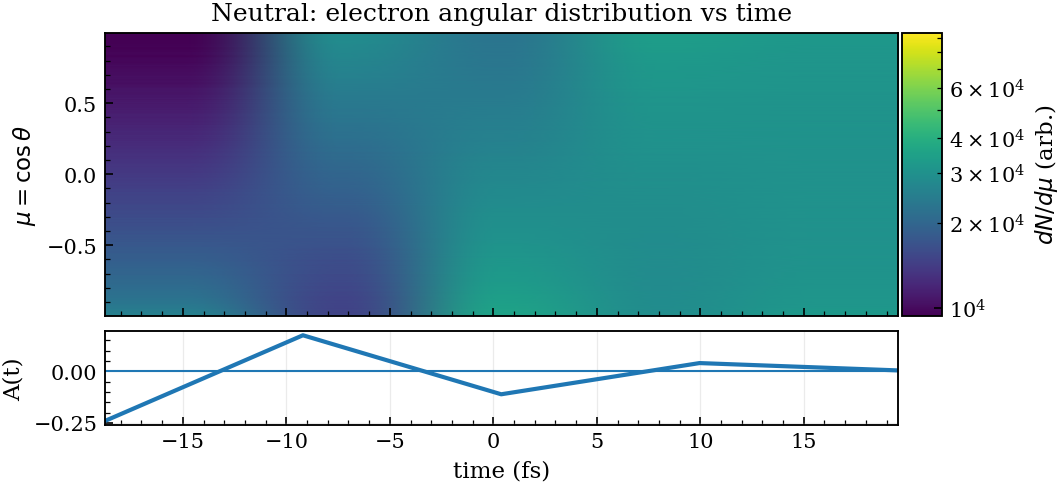

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def asymmetry_from_dNdmu(mu_mid, dNdmu_t_mu):
    H = np.asarray(dNdmu_t_mu)
    if H.shape[1] == len(mu_mid):
        Ht = H
    elif H.shape[0] == len(mu_mid):
        Ht = H.T
    else:
        raise ValueError("dNdmu shape doesn't match mu_mid.")
    mu = np.asarray(mu_mid)
    plus = mu > 0
    minus = mu < 0
    Np = np.sum(Ht[:, plus], axis=1)
    Nm = np.sum(Ht[:, minus], axis=1)
    return (Np - Nm) / (Np + Nm + 1e-300)

def _orient_mu_t(dNdmu, mu):
    H = np.asarray(dNdmu)
    # return (Nmu, Nt) for imshow with extent [tmin,tmax, mumin,mumax]
    if H.shape[0] == len(mu):
        return H
    if H.shape[1] == len(mu):
        return H.T
    raise ValueError(f"Cannot orient dNdmu with shape {H.shape} to mu length {len(mu)}")

def plot_mu_heatmap_and_asym(path, label, t_range_fs=None, vmin_mode="percentile", p_lo=0.5, p_hi=99.5):
    axes = load_axes(path)
    sp = load_spectra(path)
    t = np.asarray(axes["time_fs"])
    mu = np.asarray(axes["mu_mid"])
    dNdmu = sp["He_e_dNdmu"]

    # --- NEW: time window mask ---
    if t_range_fs is not None:
        tmin, tmax = t_range_fs
        mask_t = (t >= tmin) & (t <= tmax)
        if not np.any(mask_t):
            raise RuntimeError(f"No points in requested t_range_fs={t_range_fs}.")
        t = t[mask_t]
        dNdmu = np.asarray(dNdmu)[mask_t, :] if np.asarray(dNdmu).shape[0] == len(axes["time_fs"]) else np.asarray(dNdmu)[:, mask_t]
    # -----------------------------

    Hmu_t = _orient_mu_t(dNdmu, mu)   # (Nmu, Nt) AFTER slicing
    Ht_mu = Hmu_t.T
    A = asymmetry_from_dNdmu(mu, Ht_mu)

    Hplot = np.array(Hmu_t, dtype=float)
    Hplot[Hplot <= 0] = np.nan

    finite = Hplot[np.isfinite(Hplot)]
    if finite.size == 0:
        raise RuntimeError("All heatmap values are zero/NaN after masking.")

    if vmin_mode == "percentile":
        vmin = np.percentile(finite, p_lo)
        vmax = np.percentile(finite, p_hi)
    else:
        vmin = np.nanmin(finite)
        vmax = np.nanmax(finite)

    vmin = max(vmin, 1e-1)
    vmax = max(vmax, vmin * 10)

    fig = plt.figure(figsize=(7.2, 3.4), constrained_layout=False)
    gs = fig.add_gridspec(2, 2, width_ratios=[1.0, 0.05], height_ratios=[3, 1], wspace=0.01, hspace=0.08)

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
    cax = fig.add_subplot(gs[0, 1])

    im = ax0.imshow(
        Hplot,
        origin="lower",
        aspect="auto",
        extent=[t.min(), t.max(), mu.min(), mu.max()],
        cmap="viridis",
        norm=LogNorm(vmin=vmin, vmax=vmax),
        #interpolation="nearest",
    )
    cb = fig.colorbar(im, cax=cax)
    cb.set_label(r"$dN/d\mu$ (arb.)")

    ax0.set_ylabel(r"$\mu = \cos\theta$")
    ax0.set_title(f"{label}: electron angular distribution vs time")
    plt.setp(ax0.get_xticklabels(), visible=False)

    ax1.plot(t, A, lw=2.0)
    ax1.axhline(0, lw=1.0)
    ax1.set_ylabel("A(t)")
    ax1.set_xlabel("time (fs)")
    ax1.grid(True, alpha=0.25)

    plt.show()

# Run
plot_mu_heatmap_and_asym(H5_IONIZED, "Pre-ionized", t_range_fs=(-80, 40))
plot_mu_heatmap_and_asym(H5_NEUTRAL, "Neutral", t_range_fs=(-27, 25))

# Figure 4 — Spectral fingerprints (heatmaps)

From `/spectra` + `/axes` you can do:
- Electron spectra heatmap: `He_e_dNdE(t,E)`
- Ion spectra heatmap: `He_i_dNdE(t,E)`
- Optional: overlay a few lineouts at key times


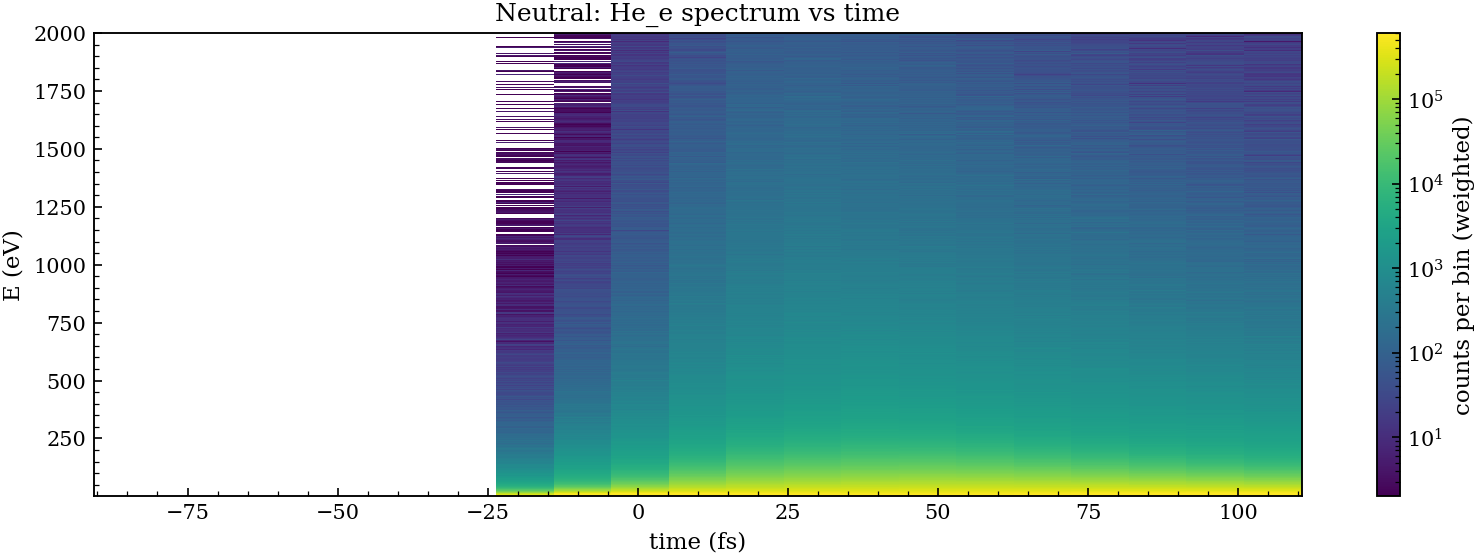

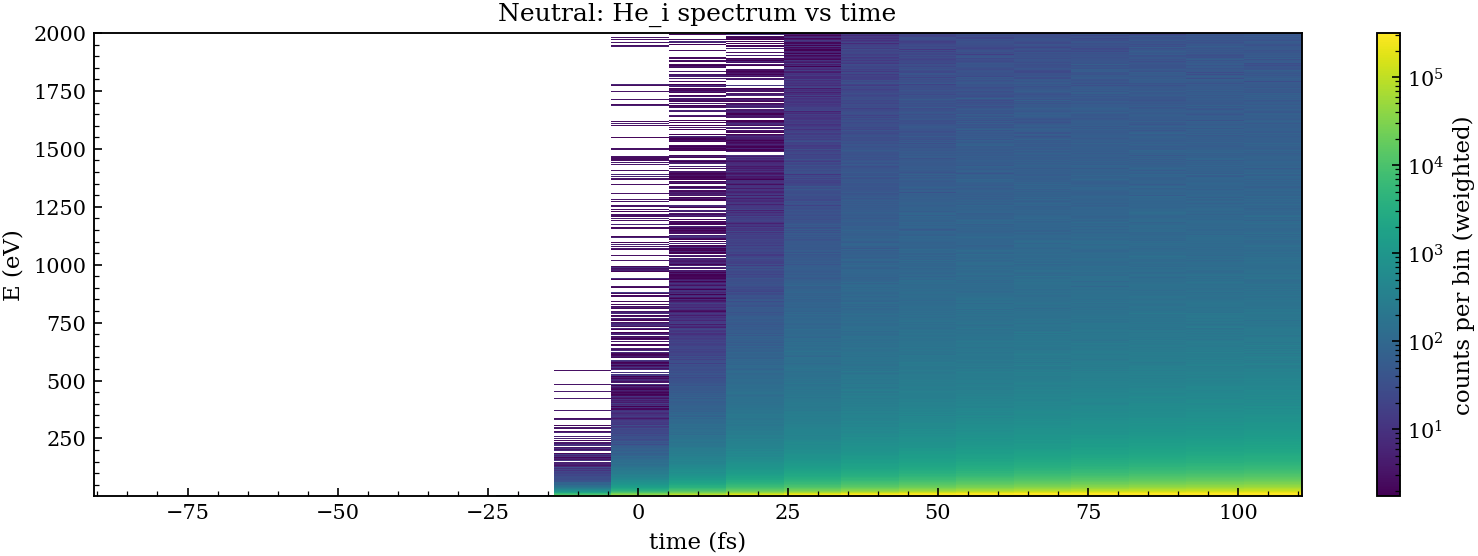

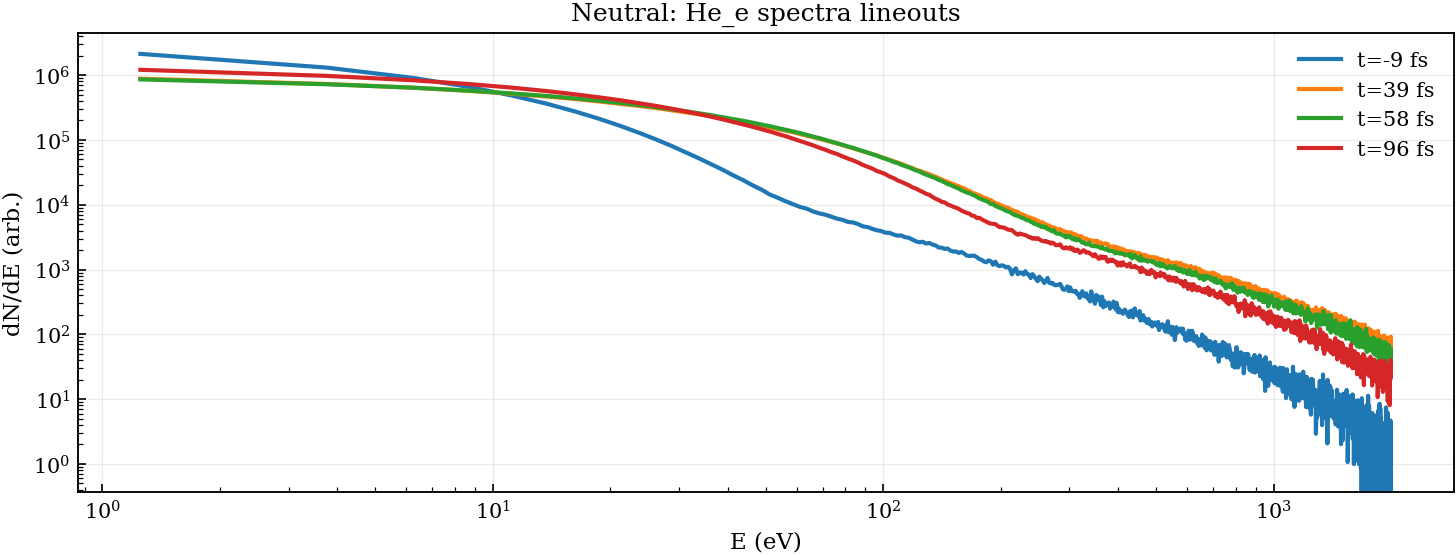

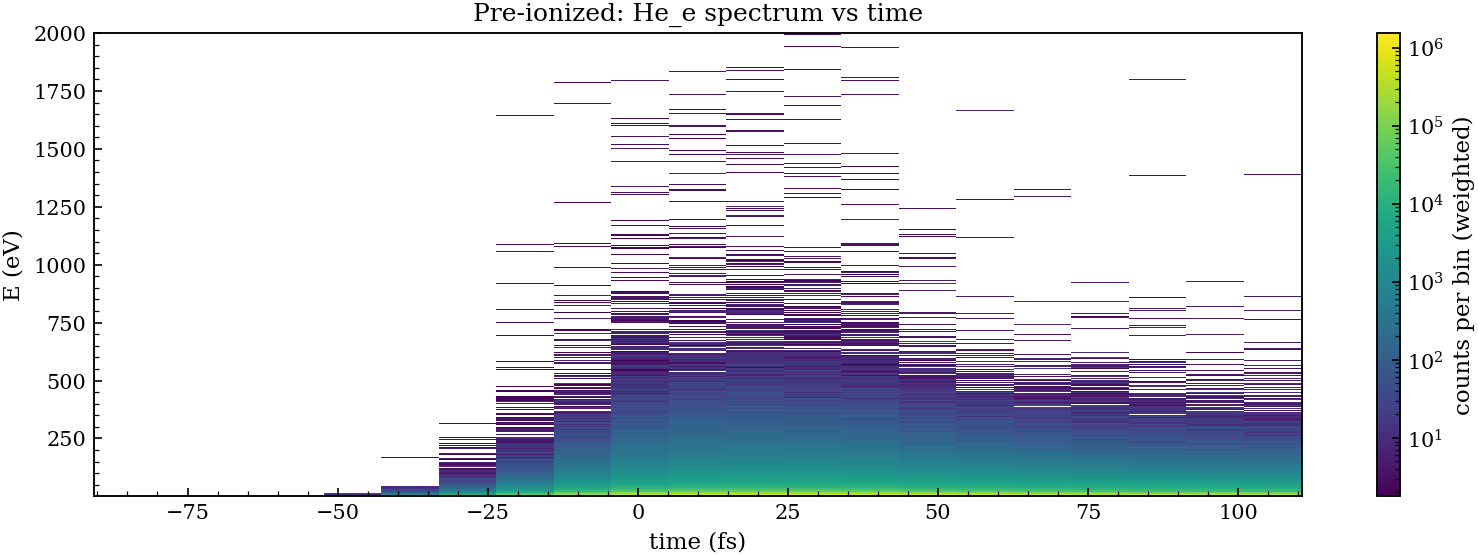

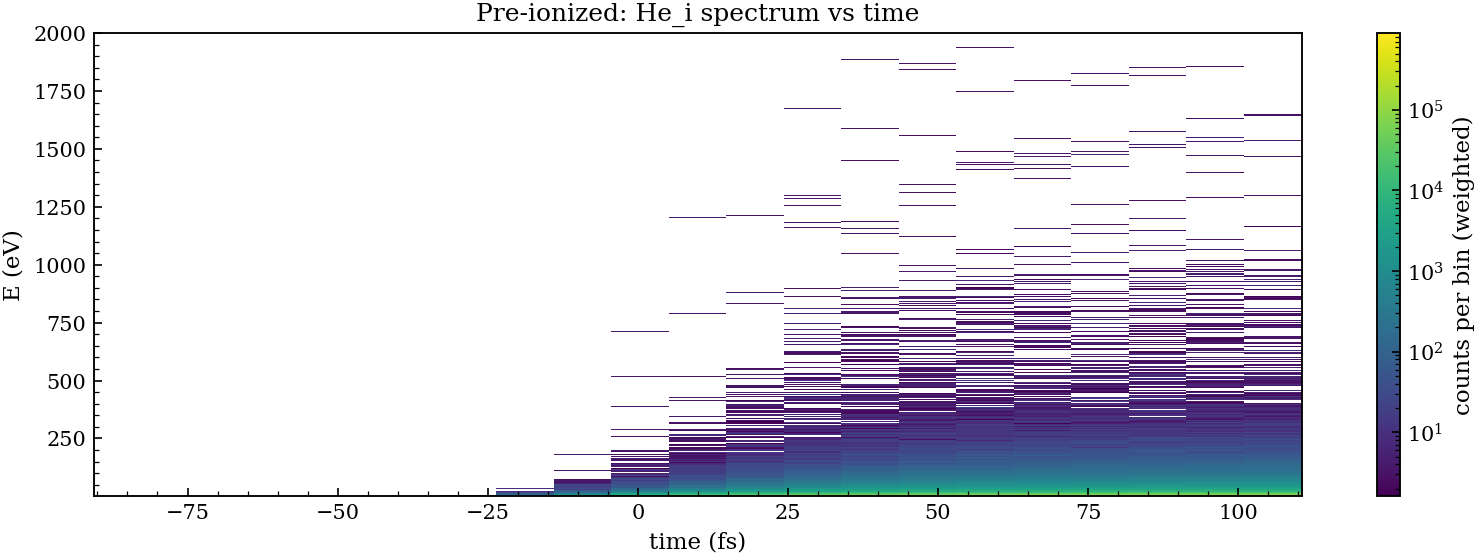

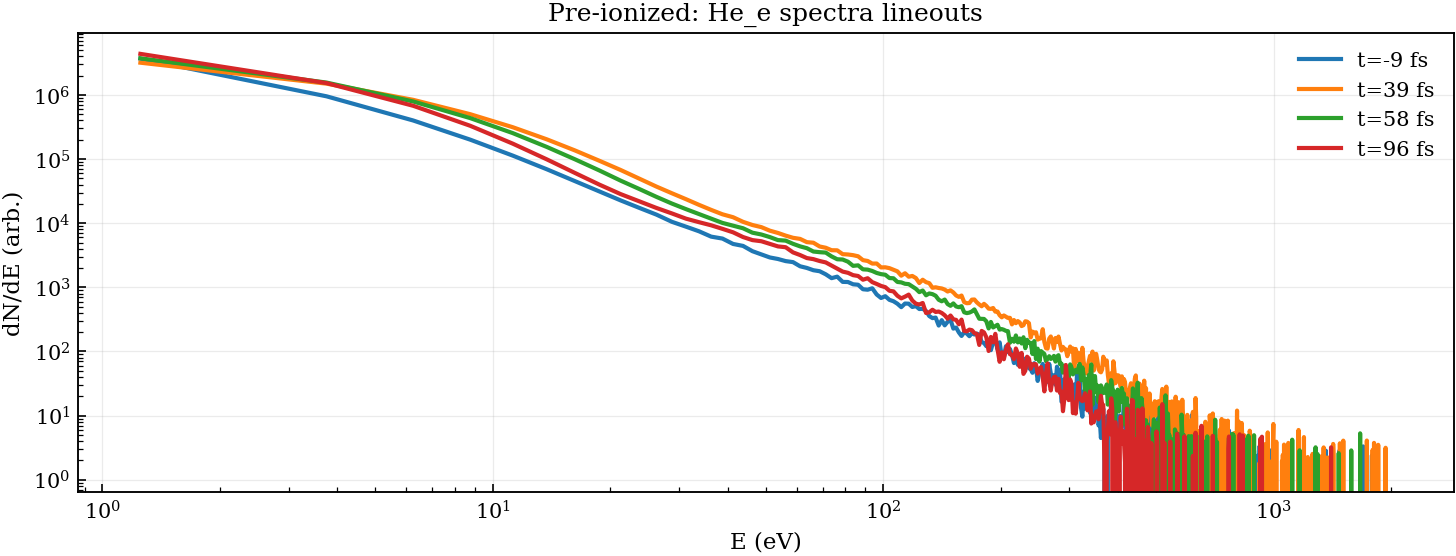

In [89]:
from matplotlib.colors import LogNorm

def plot_spectrum_heatmap(path, label, species="He_e", t_range_fs=None, vmin_p=1.0, vmax_p=99.5):
    axes = load_axes(path)
    sp = load_spectra(path)

    t = np.asarray(axes["time_fs"])
    E_edges = np.asarray(axes["E_edges_eV"])      # IMPORTANT: use edges, not mid
    E_mid   = np.asarray(axes["E_mid_eV"])

    H = np.asarray(sp[f"{species}_dNdE"])         # counts per bin (weighted)

    # ensure HtE is (Nt, NE)
    if H.shape[0] == len(t):
        HtE = H
    else:
        HtE = H.T

    # optional time window
    if t_range_fs is not None:
        tmin, tmax = t_range_fs
        m = (t >= tmin) & (t <= tmax)
        t = t[m]
        HtE = HtE[m, :]

    # mask zeros for LogNorm
    Hplot = HtE.astype(float)
    Hplot[Hplot <= 0] = np.nan
    finite = Hplot[np.isfinite(Hplot)]
    if finite.size == 0:
        raise RuntimeError("All entries are zero/NaN.")

    vmin = np.percentile(finite, vmin_p)
    vmax = np.percentile(finite, vmax_p)
    vmin = max(vmin, 1e-3)
    vmax = max(vmax, vmin * 10)

    # build time edges (uniform in time is fine)
    t_edges = np.concatenate([0.5*(t[1:]+t[:-1]), [t[-1] + (t[-1]-t[-2])/2]])
    t_edges = np.concatenate([[t[0] - (t[1]-t[0])/2], t_edges])

    plt.figure(figsize=(11,4))
    im = plt.pcolormesh(
        t_edges, E_edges, Hplot.T,   # NOTE transpose: (NE, Nt)
        norm=LogNorm(vmin=vmin, vmax=vmax),
        shading="auto",
        cmap="viridis"
    )
    plt.colorbar(im, label="counts per bin (weighted)")
    plt.xlabel("time (fs)")
    plt.ylabel("E (eV)")
    #plt.xscale("log")   # since bins are log-ish, show log y-axis
    #plt.yscale("log")   # since bins are log-ish, show log y-axis
    plt.title(f"{label}: {species} spectrum vs time")
    plt.tight_layout()
    plt.show()

def plot_lineouts(path, label, species="He_e", times_fs=(0, 50, 200)):
    axes = load_axes(path)
    sp = load_spectra(path)
    t = axes["time_fs"]
    E = axes["E_mid_eV"]
    H = sp[f"{species}_dNdE"]
    # make (Nt,NE)
    if H.shape[1] == len(E):
        HtE = H
    else:
        HtE = H.T

    plt.figure(figsize=(10,4))
    for tt in times_fs:
        i = int(np.argmin(np.abs(t-tt)))
        plt.plot(E, HtE[i], label=f"t={t[i]:.0f} fs")
    plt.xlabel("E (eV)")
    plt.ylabel("dN/dE (arb.)")
    plt.title(f"{label}: {species} spectra lineouts")
    plt.grid(True)
    plt.yscale("log")
    plt.xscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

for p,label in [(H5_NEUTRAL,"Neutral"), (H5_IONIZED,"Pre-ionized")]:
    plot_spectrum_heatmap(p, label, "He_e")
    plot_spectrum_heatmap(p, label, "He_i")
    plot_lineouts(p, label, "He_e", times_fs=(-10, 40, 60, 100))


In [94]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_combined_spectrum(
    path,
    label,
    t_range_fs=None,
    ylim_eV=None,
    yscale="linear",   # "linear" or "symlog"
    p_lo=1,
    p_hi=99.5
):

    axes = load_axes(path)
    sp = load_spectra(path)

    t = np.asarray(axes["time_fs"])
    E = np.asarray(axes["E_mid_eV"])

    H_e = np.asarray(sp["He_e_dNdE"])
    H_i = np.asarray(sp["He_i_dNdE"])

    # ensure (Nt,NE)
    HtE_e = H_e if H_e.shape[0] == len(t) else H_e.T
    HtE_i = H_i if H_i.shape[0] == len(t) else H_i.T

    # optional time window
    if t_range_fs is not None:
        tmin,tmax = t_range_fs
        m = (t>=tmin)&(t<=tmax)
        t = t[m]
        HtE_e = HtE_e[m,:]
        HtE_i = HtE_i[m,:]

    # electrons negative energy
    H_e_plot = np.flip(HtE_e,axis=1)
    H_i_plot = HtE_i

    H_combined = np.concatenate([H_e_plot,H_i_plot],axis=1)

    E_neg = -E[::-1]
    E_pos = E
    E_comb = np.concatenate([E_neg,E_pos])

    H_plot = H_combined.T.astype(float)
    H_plot[H_plot<=0] = np.nan

    finite = H_plot[np.isfinite(H_plot)]
    vmin = np.percentile(finite,p_lo)
    vmax = np.percentile(finite,p_hi)

    fig,ax = plt.subplots(figsize=(8,4))

    im = ax.imshow(
        H_plot,
        origin="lower",
        aspect="auto",
        extent=[t.min(),t.max(),E_comb.min(),E_comb.max()],
        cmap="viridis",
        norm=LogNorm(vmin=max(vmin,1e-3),vmax=vmax),
        interpolation="nearest"
    )

    ax.axhline(0,color="k",lw=1)

    # energy scaling
    if yscale == "symlog":
        ax.set_yscale("symlog",linthresh=1)

    # energy limits
    if ylim_eV is not None:
        ax.set_ylim(ylim_eV)

    ax.set_xlabel("time (fs)")
    ax.set_ylabel("Energy (eV)")
    ax.set_title(label)

    cbar = plt.colorbar(im,ax=ax)
    cbar.set_label("counts per bin (weighted)")

    ax.text(t.min()+0.02*(t.max()-t.min()),-0.8*np.max(E),"electrons",color="white")
    ax.text(t.min()+0.02*(t.max()-t.min()),0.7*np.max(E),"ions",color="white")

    plt.tight_layout()
    plt.show()

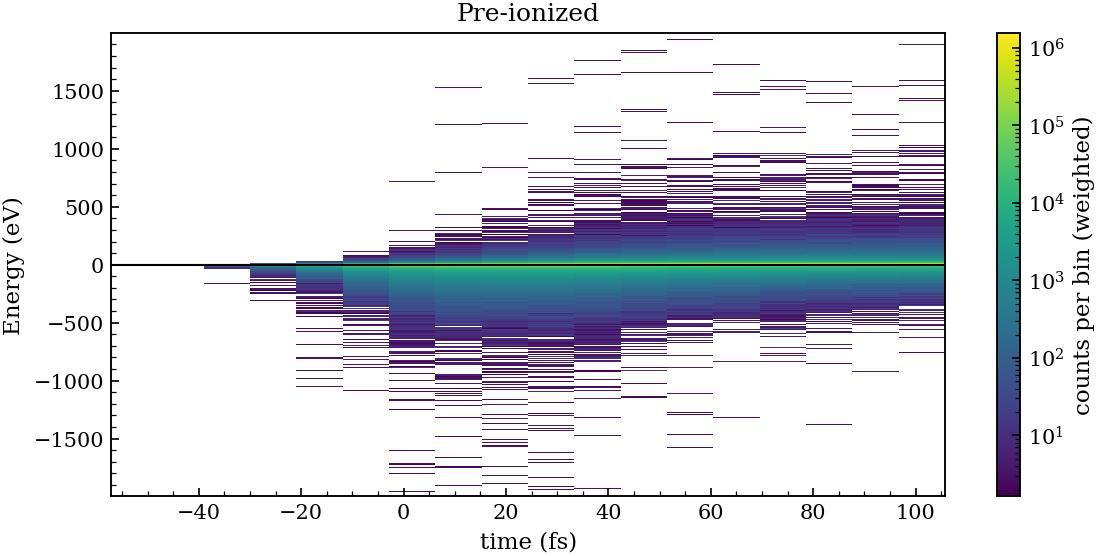

In [98]:
plot_combined_spectrum(H5_IONIZED,"Pre-ionized",t_range_fs=(-60,125))


In [140]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import scipy.constants as sc
import adios2
import glob, os

import re, glob, os

def list_bp5_sorted_by_step(openpmd_dir):
    files = glob.glob(os.path.join(openpmd_dir, "*.bp5"))
    pairs = []
    for fp in files:
        name = os.path.basename(fp)
        m = re.search(r"(\d+)\.bp5$", name)   # robust: last digits before .bp5
        if not m:
            continue
        step = int(m.group(1))
        pairs.append((step, fp))
    if not pairs:
        raise RuntimeError(f"No step-numbered .bp5 files found in {openpmd_dir}")
    pairs.sort(key=lambda x: x[0])
    return pairs
    
def _fast_weighted_hist(E_eV, w, edges):
    nb = len(edges) - 1
    idx = np.searchsorted(edges, E_eV, side="right") - 1
    m = (idx >= 0) & (idx < nb) & np.isfinite(E_eV) & np.isfinite(w)
    if not np.any(m):
        return np.zeros(nb, dtype=np.float64)
    return np.bincount(idx[m], weights=w[m], minlength=nb).astype(np.float64)

def _load_dt_fs_and_unit_time(first_bp5):
    # mirrors NanoPlasmaRun._load_meta() logic
    step0 = int(os.path.basename(first_bp5).split("_")[-1].split(".")[0])
    with adios2.Stream(first_bp5, "r") as f:
        for _ in f.steps():
            unit_time_SI = float(f.read_attribute(f"/data/{step0}/unit_time"))
            dt_code      = float(f.read_attribute(f"/data/{step0}/dt"))
            dt_fs        = (dt_code * unit_time_SI) * 1e15
    return dt_fs

def _try_read_momentum_weight_SI(f, step, species):
    """
    Returns (px_SI, py_SI, pz_SI, w) or None if species datasets are missing.
    """
    base = f"/data/{step}/particles/{species}"

    # quick existence check (fast) using available variables
    av = f.available_variables()
    need = [
        f"{base}/momentum/x",
        f"{base}/momentum/y",
        f"{base}/momentum/z",
        f"{base}/weighting",
    ]
    if any(k not in av for k in need):
        return None

    # read arrays
    px = f.read(need[0]).astype(np.float64)
    py = f.read(need[1]).astype(np.float64)
    pz = f.read(need[2]).astype(np.float64)
    w  = f.read(need[3]).astype(np.float64)

    # empty species is OK → return empty arrays (caller will handle)
    try:
        unit_p = float(f.read_attribute(f"{base}/momentum/x/unitSI"))
    except Exception:
        unit_p = 1.0

    return px*unit_p, py*unit_p, pz*unit_p, w
    
def plot_combined_spectrum_from_raw_fast(
    openpmd_dir,
    label,
    laser_peak_at_target,          # IMPORTANT for t=0 at laser peak
    species_e="He_e",
    species_i="He_i",
    ion_mass_kg=4.0*sc.atomic_mass,
    bins=320,
    Emax=250.0,
    t_range_fs=None,
    ylim_eV=None,
    yscale="linear",               # "linear" or "symlog"
    p_lo=1.0,
    p_hi=99.5,
    max_files=None,
):
    files = sorted(glob.glob(os.path.join(openpmd_dir, "*.bp5")))
    if not files:
        raise FileNotFoundError(f"No .bp5 files found in: {openpmd_dir}")
    if max_files is not None:
        files = files[:max_files]

    dt_fs = _load_dt_fs_and_unit_time(files[0])

    E_edges = np.linspace(0.0, float(Emax), int(bins) + 1)
    E_mid   = 0.5*(E_edges[1:] + E_edges[:-1])

    t_fs_list = []
    He_list, Hi_list = [], []

    # for sanity / clipping diagnostics
    e_max_seen = 0.0
    i_max_seen = 0.0
    pairs = list_bp5_sorted_by_step(openpmd_dir)
    if max_files is not None:
        pairs = pairs[:max_files]

    for step, bp in pairs:
        t_fs = (step - laser_peak_at_target) * dt_fs
        t_fs_list.append(t_fs)

        with adios2.Stream(bp, "r") as f:
            for _ in f.steps():
                # electrons
                data = _try_read_momentum_weight_SI(f, step, species_e)
                if data is None:
                    he = np.zeros(len(E_edges)-1, dtype=np.float64)
                else:
                    pxe, pye, pze, we = data
                    if pxe.size == 0:
                        he = np.zeros(len(E_edges)-1, dtype=np.float64)
                    else:
                        Ee = (pxe*pxe + pye*pye + pze*pze) / (2.0*sc.m_e) / sc.e
                        he = _fast_weighted_hist(Ee, we, E_edges)
                He_list.append(he)
                
                # ions
                data = _try_read_momentum_weight_SI(f, step, species_i)
                if data is None:
                    hi = np.zeros(len(E_edges)-1, dtype=np.float64)
                else:
                    pxi, pyi, pzi, wi = data
                    if pxi.size == 0:
                        hi = np.zeros(len(E_edges)-1, dtype=np.float64)
                    else:
                        Ei = (pxi*pxi + pyi*pyi + pzi*pzi) / (2.0*ion_mass_kg) / sc.e
                        hi = _fast_weighted_hist(Ei, wi, E_edges)
                Hi_list.append(hi)

    t = np.asarray(t_fs_list)
    HtE_e = np.vstack(He_list)  # (Nt, NE)
    HtE_i = np.vstack(Hi_list)

    # optional time window
    if t_range_fs is not None:
        tmin, tmax = t_range_fs
        m = (t >= tmin) & (t <= tmax)
        t = t[m]
        HtE_e = HtE_e[m, :]
        HtE_i = HtE_i[m, :]

    # electrons negative energy
    H_e_plot = np.flip(HtE_e, axis=1)
    H_i_plot = HtE_i
    H_comb   = np.concatenate([H_e_plot, H_i_plot], axis=1)  # (Nt, 2*NE)

    E_neg  = -E_mid[::-1]
    E_pos  =  E_mid
    E_comb = np.concatenate([E_neg, E_pos])                  # (2*NE,)

    H_plot = H_comb.T.astype(float)                          # (2*NE, Nt)

    # if Emax too small -> everything clipped -> all zeros
    total_counts = np.nansum(H_plot)
    if total_counts <= 0:
        raise RuntimeError(
            "Combined histogram is all zeros. Most likely Emax is too small (everything clipped) "
            f"or species names are wrong. Suggestion: try larger Emax. "
            f"Observed (99.99% energy) e~{e_max_seen:.2f} eV, i~{i_max_seen:.2f} eV."
        )

    # mask zeros for LogNorm
    H_plot[H_plot <= 0] = np.nan
    finite = H_plot[np.isfinite(H_plot)]
    if finite.size == 0:
        raise RuntimeError(
            "All entries became NaN after masking. Usually means all bins were zero (clipping). "
            f"Try larger Emax. Observed e~{e_max_seen:.2f} eV, i~{i_max_seen:.2f} eV."
        )

    vmin = np.percentile(finite, p_lo)
    vmax = np.percentile(finite, p_hi)
    vmin = max(vmin, 1e-3)
    vmax = max(vmax, vmin * 10)

    fig, ax = plt.subplots(figsize=(8.8, 4.2))
    im = ax.imshow(
        H_plot,
        origin="lower",
        aspect="auto",
        extent=[t.min(), t.max(), E_comb.min(), E_comb.max()],
        cmap="viridis",
        norm=LogNorm(vmin=vmin, vmax=vmax/500),
        interpolation="nearest",
    )
    ax.axhline(0, color="k", lw=1.0)

    if yscale == "symlog":
        ax.set_yscale("symlog", linthresh=1.0)

    if ylim_eV is not None:
        ax.set_ylim(ylim_eV)

    ax.set_xlabel("time (fs)  (t=0 at laser peak)")
    ax.set_ylabel("Energy (eV)   (e⁻ negative, ions positive)")
    ax.set_title(label)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("counts per bin (weighted)")

    # small labels
    ax.text(t.min() + 0.02*(t.max()-t.min()), -0.8*np.max(E_mid), "electrons", color="white")
    ax.text(t.min() + 0.02*(t.max()-t.min()),  0.7*np.max(E_mid), "ions", color="white")

    plt.tight_layout()
    plt.show()

    return t, E_mid, HtE_e, HtE_i

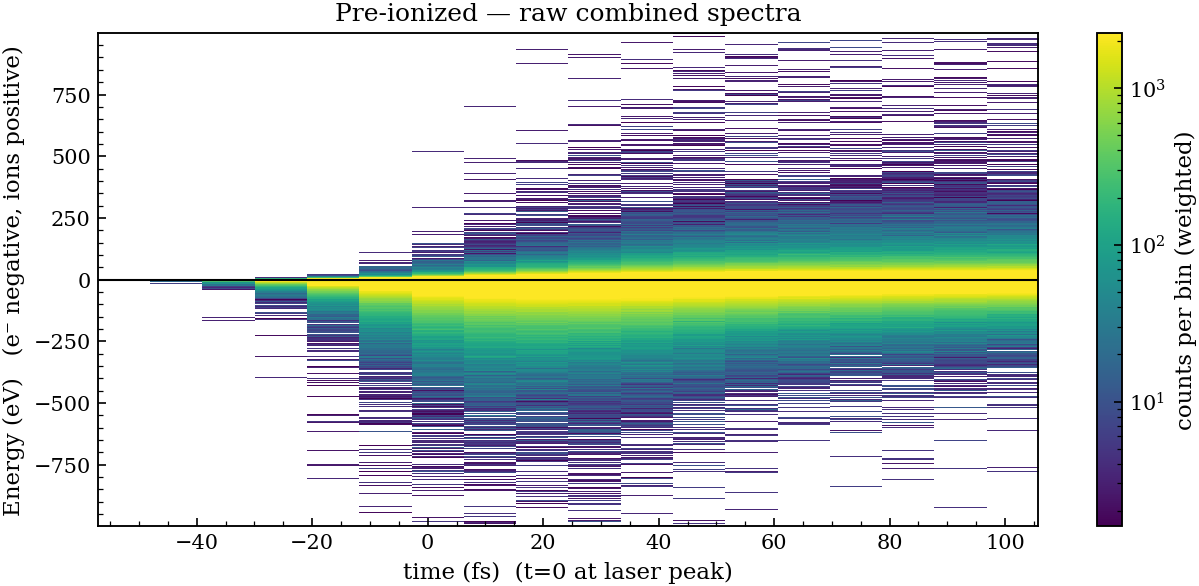

In [141]:
t, E_mid, H_e, H_i = combined_st, E, He, Hi = plot_combined_spectrum_from_raw_fast(
    openpmd_dir="/p/scratch/jureap18/medina2/2026_nanoplasma/001_OnceIonized/simOutput/openPMD",
    #openpmd_dir="/p/scratch/jureap18/medina2/2026_nanoplasma/002_NoIonized/simOutput/openPMD",
    label="Pre-ionized — raw combined spectra",
    laser_peak_at_target=89603,          # <-- put YOUR actual peak step here
    bins=640,
    Emax=1000,                             # <-- give it headroom
    t_range_fs=(-60,125),
    #ylim_eV=(-250, 250),
    #yscale="symlog",
)

# Figure 5 — Experiment comparison (VMI-style)

This is only possible **if** your reduced H5 contains 2D momentum histograms, e.g.:
- `spectra/He_e_H_pxy` and axes `axes/He_e_p_mid_SI`

If present, this cell will plot a single VMI image at a chosen time index.


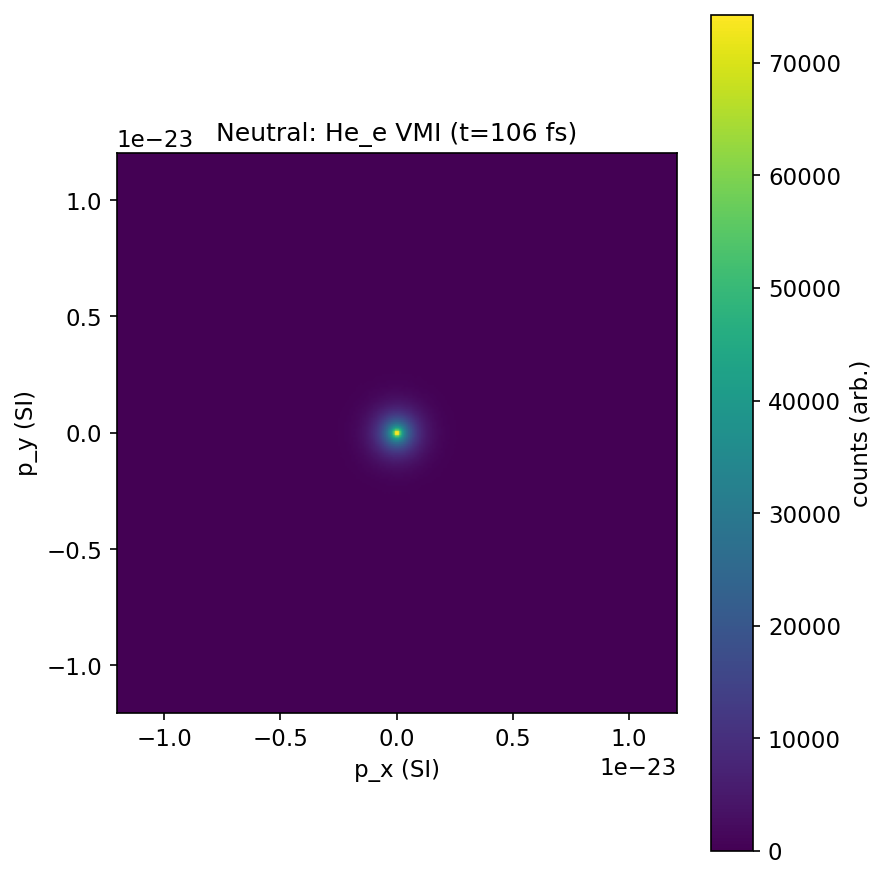

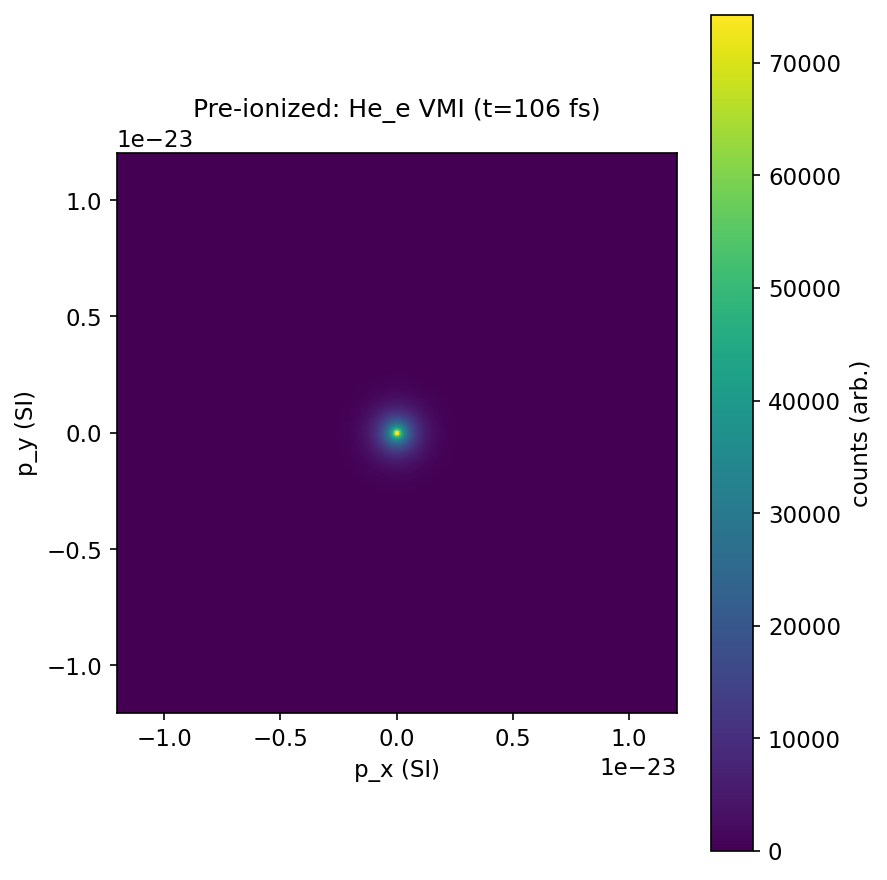

In [13]:
def plot_vmi_from_h5(path, label, species="He_e", time_index=-1):
    # optional data: spectra/{species}_H_pxy with axes/{species}_p_mid_SI
    H_key = f"spectra/{species}_H_pxy"
    p_mid_key = f"axes/{species}_p_mid_SI"

    if not h5_has(path, H_key) or not h5_has(path, p_mid_key):
        print(f"[{label}] No VMI hist found ({H_key}). Skipping.")
        return

    H = h5_read(path, H_key)        # expected (Nt, Np, Np)
    p = h5_read(path, p_mid_key)    # (Np,)

    if H.ndim != 3:
        print(f"[{label}] Unexpected shape for {H_key}: {H.shape}")
        return

    axes_ = load_axes(path)
    t = axes_["time_fs"]
    i = time_index if time_index >= 0 else (H.shape[0] + time_index)

    img = H[i]
    plt.figure(figsize=(6,6))
    plt.imshow(img, origin="lower", aspect="equal",
               extent=[p.min()/2, p.max()/2, p.min()/2, p.max()/2])
    plt.xlabel("p_x (SI)")
    plt.ylabel("p_y (SI)")
    plt.title(f"{label}: {species} VMI (t={t[i]:.0f} fs)")
    plt.colorbar(label="counts (arb.)")
    plt.tight_layout()
    plt.show()

plot_vmi_from_h5(H5_NEUTRAL, "Neutral", "He_e", time_index=-1)
plot_vmi_from_h5(H5_IONIZED, "Pre-ionized", "He_e", time_index=-1)


## Plotting parameters as SCIPY

In [187]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- Try SciencePlots first (preferred) ---
try:
    import scienceplots  # required before plt.style.use('science') in newer versions
    plt.style.use(["science", "grid", "no-latex"])
    # You can also try: ["science", "nature", "no-latex"] depending on what’s available in your install.
    USING = "SciencePlots"
except Exception as e:
    USING = f"rcParams fallback (SciencePlots not available: {type(e).__name__})"

    mpl.rcParams.update({
        # Figure / saving
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,

        # Fonts (LaTeX-like look without requiring LaTeX)
        "font.family": "serif",
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,

        # Axes
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,

        # Grid (light, paper-style)
        "grid.alpha": 0.25,
        "grid.linewidth": 0.6,
        "grid.linestyle": "-",

        # Lines
        "lines.linewidth": 2.0,
        "lines.markersize": 5,

        # Ticks
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.minor.size": 2.5,
        "ytick.minor.size": 2.5,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.minor.width": 0.6,
        "ytick.minor.width": 0.6,
        "xtick.minor.visible": True,
        "ytick.minor.visible": True,

        # Legend
        "legend.frameon": False,
    })

print("Plot style:", USING)
mpl.rcParams.update({
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.linewidth": 0.9,
})



Plot style: rcParams fallback (SciencePlots not available: ModuleNotFoundError)


In [199]:
def plot_combined_dNdE_time_x(
    path,
    label,
    t_range_fs=None,
    ylim_eV=None,
    xscale="linear",        # "linear" or "symlog"
    yscale="linear",        # "linear" or "symlog"
    linthresh_t=1e-3,       # fs: where symlog transitions to linear around 0
    linthresh_E=1.0,        # eV: same for energy
    p_lo=1.0,
    p_hi=99.5,
):
    axes = load_axes(path)
    spec = load_spectra(path)

    t = np.asarray(axes["time_fs"], float)
    E = np.asarray(axes["E_mid_eV"], float)

    He = _to_HtE(spec["He_e_dNdE"], t, E)
    Hi = _to_HtE(spec["He_i_dNdE"], t, E)

    if t_range_fs is not None:
        tmin, tmax = t_range_fs
        m = (t >= tmin) & (t <= tmax)
        t = t[m]; He = He[m,:]; Hi = Hi[m,:]

    He_plot = He[:, ::-1]
    H_comb  = np.concatenate([He_plot, Hi], axis=1)  # (Nt, 2*NE)

    if "E_edges_eV" in axes:
        E_edges = np.asarray(axes["E_edges_eV"], float)
    else:
        E_edges = _edges_from_mid(E)

    t_edges = _edges_from_mid(t)
    Eneg_edges  = -E_edges[::-1]
    Epos_edges  =  E_edges
    Ecomb_edges = np.concatenate([Eneg_edges, Epos_edges[1:]])  # no duplicated 0

    C = H_comb.T.astype(float)   # (2*NE, Nt)
    C[C <= 0] = np.nan
    finite = C[np.isfinite(C)]
    vmin = max(np.percentile(finite, p_lo), 1e-3)
    vmax = max(np.percentile(finite, p_hi), vmin*10)

    fig, ax = plt.subplots(figsize=(9.2, 4.6))
    im = ax.pcolormesh(
        t_edges, Ecomb_edges, C,
        shading="auto",
        norm=LogNorm(vmin=vmin, vmax=vmax),
        cmap="viridis",
    )

    ax.axhline(0, color="k", lw=1.0)
    ax.axvline(0, color="k", lw=1.0)

    # symlog options
    if xscale == "symlog":
        ax.set_xscale("symlog", linthresh=linthresh_t)
    else:
        ax.set_xscale("linear")

    if yscale == "symlog":
        ax.set_yscale("symlog", linthresh=linthresh_E)
    else:
        ax.set_yscale("linear")

    if ylim_eV is not None:
        ax.set_ylim(ylim_eV)

    ax.set_xlabel("time (fs)")
    ax.set_ylabel("Energy (eV)  (e⁻ negative, ions positive)")
    ax.set_title(label)

    cb = fig.colorbar(im, ax=ax)
    cb.set_label("dN/dE (weighted)  [as exported]")

    plt.tight_layout()
    plt.show()

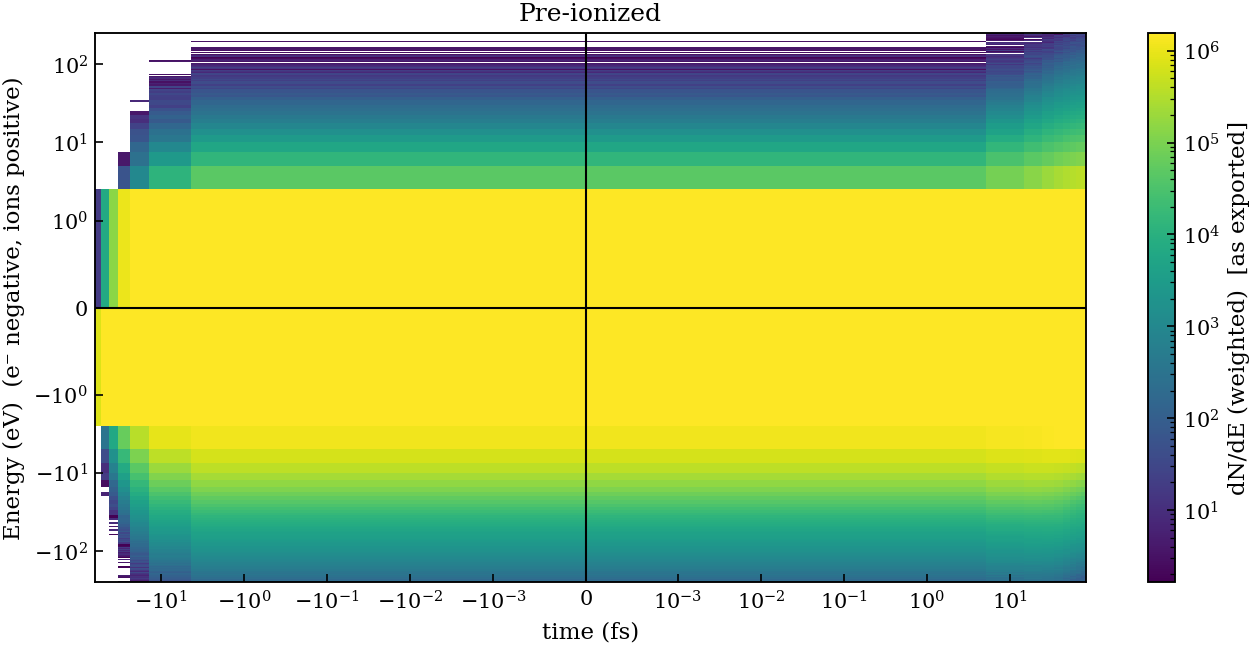

In [200]:
plot_combined_dNdE_time_x(
    H5_IONIZED, "Pre-ionized",
    t_range_fs=(-60, 80),
    ylim_eV=(-250, 250),
    xscale="symlog", yscale="symlog",
    linthresh_t=1e-3,   # fs
    linthresh_E=1.0,    # eV
)
#plot_combined_dNdE_time_x(H5_NEUTRAL, "Neutral",    t_range_fs=(-60, 80), ylim_eV=(-250, 250), yscale="linear")